# Fixed Binary Swin Notebook

This cleaned version keeps one consistent pipeline:

- `0 = healthy`
- `1 = unhealthy`
- reads **processed images** from `processed_full_path`
- uses **stratified** train/val/test splits
- runs a **working Optuna search**
- reports metrics with **unhealthy as the positive class**


In [2]:
!pip install optuna

In [2]:
import copy
import os
import random
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import models, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Using device: cuda


In [3]:
from pathlib import Path

# Try a few likely locations for the DDR CSV
CSV_CANDIDATES = [
    Path("DR_grading.csv"),
    Path.cwd() / "DR_grading.csv",
    Path.home() / "SageMaker" / "DR_grading.csv",
    Path.home() / "SageMaker" / "DDR" / "DR_grading.csv",
    Path.home() / "SageMaker" / "DDRT" / "DR_grading.csv",
]

ORIGINAL_CSV = next((p for p in CSV_CANDIDATES if p.exists()), None)
if ORIGINAL_CSV is None:
    raise FileNotFoundError(
        "Could not find DR_grading.csv. Checked:\n" +
        "\n".join(str(p) for p in CSV_CANDIDATES)
    )

SAVE_ROOT = Path.home() / "SageMaker" / "binary_processed_output"
SAVE_ROOT.mkdir(parents=True, exist_ok=True)

PROCESSED_DIR_CANDIDATES = [
    SAVE_ROOT / "binary processed",
    Path("/tmp/binary processed"),
]

PROCESSED_DIR = next((p for p in PROCESSED_DIR_CANDIDATES if p.exists()), None)
if PROCESSED_DIR is None:
    raise FileNotFoundError(
        "Could not find processed images folder. Checked:\n" +
        "\n".join(str(p) for p in PROCESSED_DIR_CANDIDATES)
    )

CLEANED_CSV = SAVE_ROOT / "binary_processed_fixed.csv"
MODEL_PATH = SAVE_ROOT / "best_binary_swin_t_fixed.pth"

print("Original CSV:", ORIGINAL_CSV)
print("Processed images:", PROCESSED_DIR)
print("Cleaned CSV:", CLEANED_CSV)
print("Model path:", MODEL_PATH)


Original CSV: /home/ec2-user/SageMaker/DR_grading.csv
Processed images: /home/ec2-user/SageMaker/binary_processed_output/binary processed
Cleaned CSV: /home/ec2-user/SageMaker/binary_processed_output/binary_processed_fixed.csv
Model path: /home/ec2-user/SageMaker/binary_processed_output/best_binary_swin_t_fixed.pth


In [4]:
"""ORIGINAL_CSV = Path("DR_grading.csv")
SAVE_ROOT = Path.home() / "SageMaker" / "binary_processed_output"
SAVE_ROOT.mkdir(parents=True, exist_ok=True)

PROCESSED_DIR = SAVE_ROOT / "binary processed"
if not PROCESSED_DIR.exists():
    PROCESSED_DIR = Path("/tmp/binary processed")

CLEANED_CSV = SAVE_ROOT / "binary_processed_fixed.csv"
MODEL_PATH = SAVE_ROOT / "best_binary_swin_t_fixed.pth"

print("Original CSV:", ORIGINAL_CSV)
print("Processed images:", PROCESSED_DIR)
print("Cleaned CSV:", CLEANED_CSV)
print("Model path:", MODEL_PATH)

if not ORIGINAL_CSV.exists():
    raise FileNotFoundError(f"Missing CSV: {ORIGINAL_CSV}")

if not PROCESSED_DIR.exists():
    raise FileNotFoundError(f"Missing processed image folder: {PROCESSED_DIR}")"""


'ORIGINAL_CSV = Path("DR_grading.csv")\nSAVE_ROOT = Path.home() / "SageMaker" / "binary_processed_output"\nSAVE_ROOT.mkdir(parents=True, exist_ok=True)\n\nPROCESSED_DIR = SAVE_ROOT / "binary processed"\nif not PROCESSED_DIR.exists():\n    PROCESSED_DIR = Path("/tmp/binary processed")\n\nCLEANED_CSV = SAVE_ROOT / "binary_processed_fixed.csv"\nMODEL_PATH = SAVE_ROOT / "best_binary_swin_t_fixed.pth"\n\nprint("Original CSV:", ORIGINAL_CSV)\nprint("Processed images:", PROCESSED_DIR)\nprint("Cleaned CSV:", CLEANED_CSV)\nprint("Model path:", MODEL_PATH)\n\nif not ORIGINAL_CSV.exists():\n    raise FileNotFoundError(f"Missing CSV: {ORIGINAL_CSV}")\n\nif not PROCESSED_DIR.exists():\n    raise FileNotFoundError(f"Missing processed image folder: {PROCESSED_DIR}")'

In [5]:
df = pd.read_csv(ORIGINAL_CSV)
df.columns = [c.strip().lower() for c in df.columns]
assert "id_code" in df.columns and "diagnosis" in df.columns

# Keep one label definition everywhere:
# 0 = healthy, 1 = unhealthy
df["diagnosis"] = df["diagnosis"].astype(int).apply(lambda x: 0 if x == 0 else 1)

def processed_path_from_id(image_id: str) -> str:
    stem = Path(str(image_id)).stem
    return str(PROCESSED_DIR / f"{stem}.png")

df["processed_full_path"] = df["id_code"].apply(processed_path_from_id)
df = df[df["processed_full_path"].apply(os.path.exists)].reset_index(drop=True)
df.to_csv(CLEANED_CSV, index=False)

print("Rows kept:", len(df))
print("Label distribution (0=healthy, 1=unhealthy):")
print(df["diagnosis"].value_counts().sort_index())
display(df.head())


Rows kept: 12520
Label distribution (0=healthy, 1=unhealthy):
diagnosis
0    6265
1    6255
Name: count, dtype: int64


,id_code,diagnosis,processed_full_path
0,20170413102628830.jpg,0,/home/ec2-user/SageMaker/binary_processed_outp...
1,20170413111955404.jpg,0,/home/ec2-user/SageMaker/binary_processed_outp...
2,20170413112015395.jpg,0,/home/ec2-user/SageMaker/binary_processed_outp...
3,20170413112017305.jpg,0,/home/ec2-user/SageMaker/binary_processed_outp...
4,20170413112528859.jpg,0,/home/ec2-user/SageMaker/binary_processed_outp...


In [6]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["diagnosis"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["diagnosis"],
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print("\nTrain distribution:")
print(train_df["diagnosis"].value_counts(normalize=True).sort_index())
print("\nVal distribution:")
print(val_df["diagnosis"].value_counts(normalize=True).sort_index())
print("\nTest distribution:")
print(test_df["diagnosis"].value_counts(normalize=True).sort_index())


Train: 8764 | Val: 1878 | Test: 1878

Train distribution:
diagnosis
0    0.500342
1    0.499658
Name: proportion, dtype: float64

Val distribution:
diagnosis
0    0.500532
1    0.499468
Name: proportion, dtype: float64

Test distribution:
diagnosis
0    0.500532
1    0.499468
Name: proportion, dtype: float64


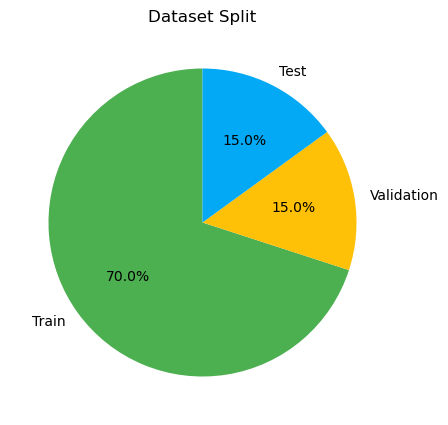

In [7]:
plt.figure(figsize=(5, 5))
plt.pie(
    [len(train_df), len(val_df), len(test_df)],
    labels=["Train", "Validation", "Test"],
    autopct="%1.1f%%",
    colors=["#4CAF50", "#FFC107", "#03A9F4"],
    startangle=90,
)
plt.title("Dataset Split")
plt.show()


In [8]:
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.08, contrast=0.08),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

class DDRDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["processed_full_path"]
        label = int(row["diagnosis"])

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, label

train_ds = DDRDataset(train_df, transform=train_transform)
val_ds = DDRDataset(val_df, transform=val_transform)
test_ds = DDRDataset(test_df, transform=val_transform)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")


Train: 8764 | Val: 1878 | Test: 1878


Image shape: torch.Size([3, 224, 224])
Label: 0 (0=healthy, 1=unhealthy)


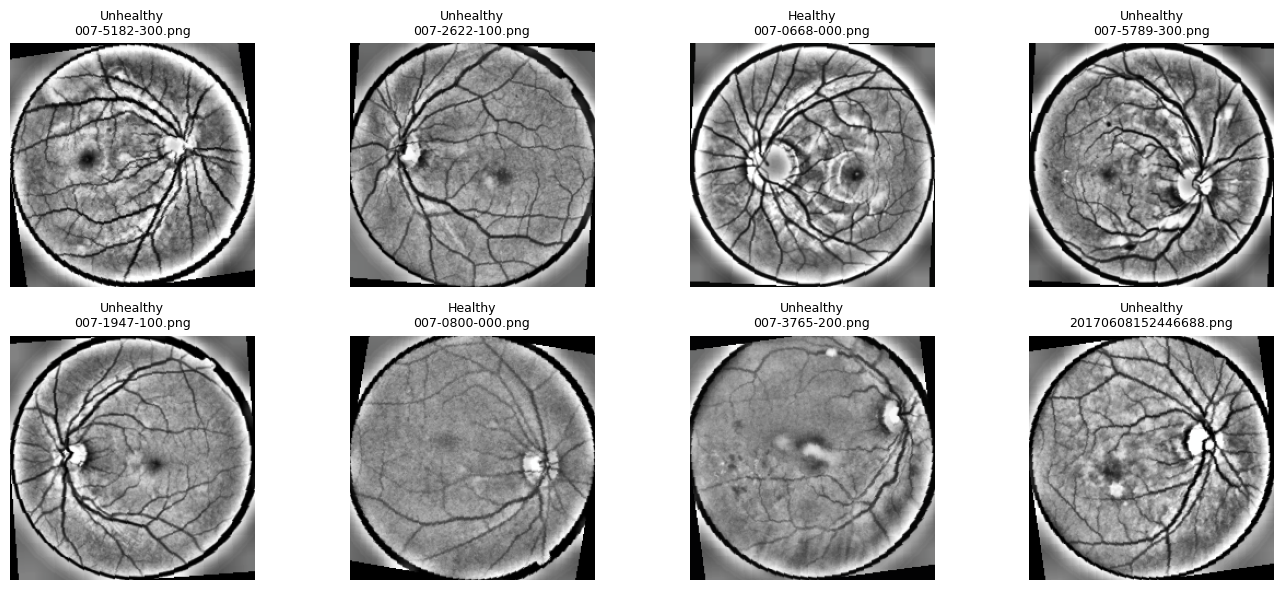

In [9]:
img, label = train_ds[0]
print("Image shape:", img.shape)
print("Label:", label, "(0=healthy, 1=unhealthy)")

indices = random.sample(range(len(train_ds)), 8)
plt.figure(figsize=(14, 6))

for i, idx in enumerate(indices):
    img_tensor, y = train_ds[idx]
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img_np = np.clip(img_np, 0, 1)

    label_str = "Unhealthy" if y == 1 else "Healthy"
    filename = Path(train_ds.df.iloc[idx]["processed_full_path"]).name

    plt.subplot(2, 4, i + 1)
    plt.imshow(img_np)
    plt.title(f"{label_str}\n{filename}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [10]:
def _model_forward(model, images):
    logits = model(images)
    if logits.ndim == 2 and logits.size(-1) == 1:
        logits = logits.squeeze(-1)
    return logits

@torch.no_grad()
def _evaluate(model, loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss = 0.0
    all_logits = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().to(device).view(-1)

        logits = _model_forward(model, images)
        loss = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        all_logits.append(logits.detach().cpu())
        all_labels.append(labels.detach().cpu())

    avg_loss = total_loss / len(loader.dataset)
    logits_np = torch.cat(all_logits).numpy()
    labels_np = torch.cat(all_labels).numpy().astype(int)
    probs_np = 1.0 / (1.0 + np.exp(-logits_np))
    preds_np = (probs_np >= threshold).astype(int)

    metrics = {
        "loss": avg_loss,
        "acc": accuracy_score(labels_np, preds_np),
        "prec": precision_score(labels_np, preds_np, zero_division=0),
        "rec": recall_score(labels_np, preds_np, zero_division=0),
        "f1": f1_score(labels_np, preds_np, zero_division=0),
    }
    try:
        metrics["auc"] = roc_auc_score(labels_np, probs_np)
    except ValueError:
        metrics["auc"] = 0.0

    return metrics, probs_np, labels_np

def find_optimal_threshold(labels, probs):
    precision, recall, thresholds = precision_recall_curve(labels, probs)
    if len(thresholds) == 0:
        return 0.5, 0.0

    f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-10)
    best_idx = int(np.argmax(f1_scores))
    return float(thresholds[best_idx]), float(f1_scores[best_idx])


In [9]:
# Stable Optuna subset for speed
subset_size = min(1000, len(train_ds))
search_rng = np.random.default_rng(SEED)
search_idx = search_rng.choice(len(train_ds), size=subset_size, replace=False)
optuna_subset_ds = Subset(train_ds, search_idx)

def swin_objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 5e-4, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-4, 1e-1, log=True)
    dropout = trial.suggest_float("dropout", 0.0, 0.5)

    model = models.swin_t(weights=models.Swin_T_Weights.DEFAULT)
    in_features = model.head.in_features
    model.head = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, 1),
    )
    model = model.to(device)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()

    optuna_train_loader = DataLoader(
        optuna_subset_ds,
        batch_size=32,
        shuffle=True,
        num_workers=0,
    )
    optuna_val_loader = DataLoader(
        val_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
    )

    best_f1 = 0.0

    for epoch in range(3):
        model.train()
        for images, labels in optuna_train_loader:
            images = images.to(device)
            labels = labels.float().to(device).view(-1)

            optimizer.zero_grad()
            logits = _model_forward(model, images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

        val_metrics, _, _ = _evaluate(model, optuna_val_loader, criterion, device)
        best_f1 = max(best_f1, val_metrics["f1"])

        print(
            f"Trial {trial.number:02d} | "
            f"Epoch {epoch + 1}/3 | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val F1: {val_metrics['f1']:.4f}"
        )

        trial.report(val_metrics["f1"], epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_f1

study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
study.optimize(swin_objective, n_trials=15)

best_params = study.best_params
print("\nBest F1:", study.best_value)
print("Best parameters:", best_params)


[I 2026-04-22 12:21:03,903] A new study created in memory with name: no-name-0c65ebcd-c190-40ef-98b0-0defb54456ab


Trial 00 | Epoch 1/3 | Val Loss: 0.6053 | Val F1: 0.5349
Trial 00 | Epoch 2/3 | Val Loss: 0.5576 | Val F1: 0.7540


[I 2026-04-22 12:22:26,048] Trial 0 finished with value: 0.7950236966824644 and parameters: {'lr': 0.00020457379122891753, 'weight_decay': 0.07745119022936224, 'dropout': 0.03916146723580105}. Best is trial 0 with value: 0.7950236966824644.


Trial 00 | Epoch 3/3 | Val Loss: 0.4199 | Val F1: 0.7950
Trial 01 | Epoch 1/3 | Val Loss: 0.6115 | Val F1: 0.4813
Trial 01 | Epoch 2/3 | Val Loss: 0.5177 | Val F1: 0.7710


[I 2026-04-22 12:23:47,962] Trial 1 finished with value: 0.771 and parameters: {'lr': 0.0001730224466761007, 'weight_decay': 0.0001416773849814181, 'dropout': 0.18100436913198148}. Best is trial 0 with value: 0.7950236966824644.


...

Trial 12 | Epoch 2/3 | Val Loss: 0.6372 | Val F1: 0.4910
Trial 13 | Epoch 1/3 | Val Loss: 0.5348 | Val F1: 0.7250


[I 2026-04-22 12:37:02,491] Trial 13 pruned. 


Trial 13 | Epoch 2/3 | Val Loss: 0.5114 | Val F1: 0.6838
Trial 14 | Epoch 1/3 | Val Loss: 0.4683 | Val F1: 0.7593


[I 2026-04-22 12:37:57,607] Trial 14 pruned. 


Trial 14 | Epoch 2/3 | Val Loss: 0.5229 | Val F1: 0.6943

Best F1: 0.8229813664596274
Best parameters: {'lr': 1.774687920320045e-05, 'weight_decay': 0.0001312939452487751, 'dropout': 0.10531542163373908}


In [11]:
best_params= {'lr': 1.774687920320045e-05, 'weight_decay': 0.0001312939452487751, 'dropout': 0.10531542163373908}

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_ds,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_ds,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=torch.cuda.is_available(),
)


In [12]:
print("\nStarting final training...")

final_model = models.swin_t(weights=models.Swin_T_Weights.DEFAULT)
in_features = final_model.head.in_features
final_model.head = nn.Sequential(
    nn.Dropout(p=best_params["dropout"]),
    nn.Linear(in_features, 1),
)
final_model = final_model.to(device)

optimizer = optim.AdamW(
    final_model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"],
)
criterion = nn.BCEWithLogitsLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=5,
)

epochs = 100
early_stopping_patience = 10
early_stopping_counter = 0

history = {"train_loss": [], "val_loss": [], "val_f1": []}
best_val_f1 = 0.0
best_model_wts = copy.deepcopy(final_model.state_dict())

for epoch in range(epochs):
    final_model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().to(device).view(-1)

        optimizer.zero_grad()
        logits = _model_forward(final_model, images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    val_metrics, val_probs, val_labels = _evaluate(final_model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_f1"].append(val_metrics["f1"])

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f}"
    )

    scheduler.step(val_metrics["loss"])

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        best_model_wts = copy.deepcopy(final_model.state_dict())
        early_stopping_counter = 0
        print("  --> New best model")
    else:
        early_stopping_counter += 1
        print(f"  --> No improvement. Patience: {early_stopping_counter}/{early_stopping_patience}")

    if early_stopping_counter >= early_stopping_patience:
        print("\nEarly stopping triggered.")
        break

final_model.load_state_dict(best_model_wts)
print("\nBest validation F1:", best_val_f1)



Starting final training...
Epoch 1/100 | Train Loss: 0.4758 | Val Loss: 0.3457 | Val F1: 0.8487
  --> New best model
Epoch 2/100 | Train Loss: 0.3951 | Val Loss: 0.3150 | Val F1: 0.8506
  --> New best model
Epoch 3/100 | Train Loss: 0.3675 | Val Loss: 0.3105 | Val F1: 0.8506
  --> New best model
Epoch 4/100 | Train Loss: 0.3311 | Val Loss: 0.2907 | Val F1: 0.8796
  --> New best model
Epoch 5/100 | Train Loss: 0.3193 | Val Loss: 0.2753 | Val F1: 0.8847
  --> New best model
Epoch 6/100 | Train Loss: 0.2976 | Val Loss: 0.2836 | Val F1: 0.8648
  --> No improvement. Patience: 1/10
Epoch 7/100 | Train Loss: 0.2893 | Val Loss: 0.2657 | Val F1: 0.8899
  --> New best model
Epoch 8/100 | Train Loss: 0.2836 | Val Loss: 0.2591 | Val F1: 0.8733
  --> No improvement. Patience: 1/10
Epoch 9/100 | Train Loss: 0.2684 | Val Loss: 0.2422 | Val F1: 0.9028
  --> New best model
Epoch 10/100 | Train Loss: 0.2618 | Val Loss: 0.2344 | Val F1: 0.8899
  --> No improvement. Patience: 1/10
Epoch 11/100 | Train Lo

In [13]:
final_model.load_state_dict(best_model_wts)

_, val_probs, val_labels = _evaluate(final_model, val_loader, criterion, device)
best_threshold, best_threshold_f1 = find_optimal_threshold(val_labels, val_probs)

print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Validation F1 at optimal threshold: {best_threshold_f1:.4f}")

test_metrics, test_probs, test_labels = _evaluate(
    final_model,
    test_loader,
    criterion,
    device,
    threshold=best_threshold,
)
test_preds = (test_probs >= best_threshold).astype(int)

print("\n" + "=" * 32)
print("FINAL TEST RESULTS")
print("=" * 32)
print(f"Accuracy:  {test_metrics['acc']:.4f}")
print(f"F1 Score:  {test_metrics['f1']:.4f}")
print(f"AUC Score: {test_metrics['auc']:.4f}")
print(f"Precision: {test_metrics['prec']:.4f}")
print(f"Recall:    {test_metrics['rec']:.4f}")
print("-" * 32)

cm = confusion_matrix(test_labels, test_preds)
print("\nConfusion Matrix [rows=true, cols=pred]:")
print(cm)

print("\nClassification report (positive class = unhealthy):")
print(classification_report(test_labels, test_preds, target_names=["Healthy", "Unhealthy"], zero_division=0))


Optimal threshold: 0.5006
Validation F1 at optimal threshold: 0.9156

FINAL TEST RESULTS
Accuracy:  0.9004
F1 Score:  0.9007
AUC Score: 0.9626
Precision: 0.8974
Recall:    0.9041
--------------------------------

Confusion Matrix [rows=true, cols=pred]:
[[843  97]
 [ 90 848]]

Classification report (positive class = unhealthy):
              precision    recall  f1-score   support

     Healthy       0.90      0.90      0.90       940
   Unhealthy       0.90      0.90      0.90       938

    accuracy                           0.90      1878
   macro avg       0.90      0.90      0.90      1878
weighted avg       0.90      0.90      0.90      1878



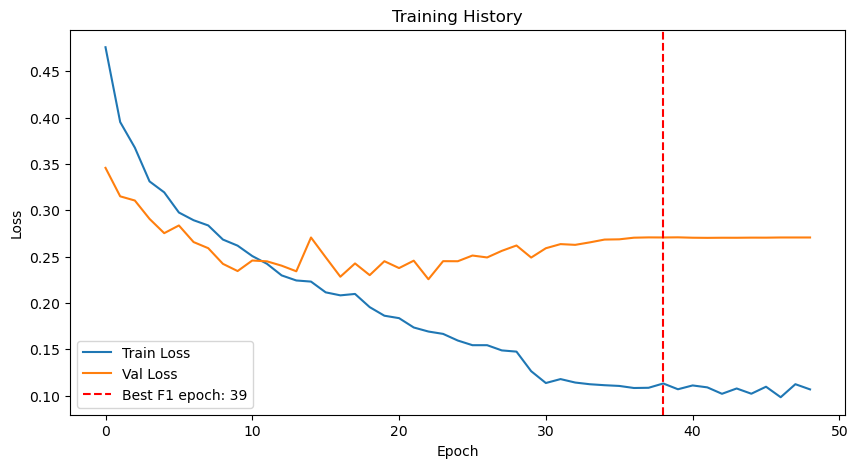

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
best_epoch = int(np.argmax(history["val_f1"]))
plt.axvline(best_epoch, color="red", linestyle="--", label=f"Best F1 epoch: {best_epoch + 1}")
plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [15]:
save_data = {
    "model_state_dict": final_model.state_dict(),
    "best_threshold": best_threshold,
    "best_params": best_params,
    "model_name": "Swin-T",
    "input_size": (IMAGE_SIZE, IMAGE_SIZE),
    "label_mapping": {"healthy": 0, "unhealthy": 1},
    "processed_csv": str(CLEANED_CSV),
}

torch.save(save_data, MODEL_PATH)
print(f"Saved model to: {MODEL_PATH}")


Saved model to: /home/ec2-user/SageMaker/binary_processed_output/best_binary_swin_t_fixed.pth


In [18]:
from pathlib import Path
from datetime import datetime
import copy
import torch
import torch.nn as nn
from torchvision import models

CKPT_PATH = Path("/home/ec2-user/SageMaker/binary_processed_output/best_binary_swin_t_fixed.pth")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not CKPT_PATH.exists():
    raise FileNotFoundError(f"Checkpoint not found: {CKPT_PATH}")

print("Checkpoint:", CKPT_PATH)
print("Last modified:", datetime.fromtimestamp(CKPT_PATH.stat().st_mtime))

ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)

print("\nSaved keys:")
if isinstance(ckpt, dict):
    print(list(ckpt.keys()))
else:
    print(type(ckpt))

best_threshold = ckpt.get("best_threshold", 0.5) if isinstance(ckpt, dict) else 0.5
best_params = ckpt.get("best_params", {}) if isinstance(ckpt, dict) else {}
dropout = best_params.get("dropout", 0.2)

print("\nLoaded threshold:", best_threshold)
print("Loaded best_params:", best_params)
print("Loaded dropout:", dropout)

final_model = models.swin_t(weights=None)
in_features = final_model.head.in_features
final_model.head = nn.Sequential(
    nn.Dropout(p=dropout),
    nn.Linear(in_features, 1)
)

state = ckpt["model_state_dict"] if isinstance(ckpt, dict) and "model_state_dict" in ckpt else ckpt
state = {k.replace("module.", ""): v for k, v in state.items()}

final_model.load_state_dict(state, strict=False)
final_model = final_model.to(DEVICE)
final_model.eval()

best_model_wts = copy.deepcopy(final_model.state_dict())

print("\nCheckpoint loaded successfully.")


Checkpoint: /home/ec2-user/SageMaker/binary_processed_output/best_binary_swin_t_fixed.pth
Last modified: 2026-04-22 15:24:31.515567

Saved keys:
['model_state_dict', 'best_threshold', 'best_params', 'model_name', 'input_size', 'label_mapping', 'processed_csv']

Loaded threshold: 0.5005577206611633
Loaded best_params: {'lr': 1.774687920320045e-05, 'weight_decay': 0.0001312939452487751, 'dropout': 0.10531542163373908}
Loaded dropout: 0.10531542163373908

Checkpoint loaded successfully.


In [19]:


_, val_probs, val_labels = _evaluate(final_model, val_loader, criterion, device)
best_threshold, best_threshold_f1 = find_optimal_threshold(val_labels, val_probs)

print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Validation F1 at optimal threshold: {best_threshold_f1:.4f}")

test_metrics, test_probs, test_labels = _evaluate(
    final_model,
    test_loader,
    criterion,
    device,
    threshold=best_threshold,
)
test_preds = (test_probs >= best_threshold).astype(int)

print("\n" + "=" * 32)
print("FINAL TEST RESULTS")
print("=" * 32)
print(f"Accuracy:  {test_metrics['acc']:.4f}")
print(f"F1 Score:  {test_metrics['f1']:.4f}")
print(f"AUC Score: {test_metrics['auc']:.4f}")
print(f"Precision: {test_metrics['prec']:.4f}")
print(f"Recall:    {test_metrics['rec']:.4f}")
print("-" * 32)

cm = confusion_matrix(test_labels, test_preds)
print("\nConfusion Matrix [rows=true, cols=pred]:")
print(cm)

print("\nClassification report (positive class = unhealthy):")
print(classification_report(test_labels, test_preds, target_names=["Healthy", "Unhealthy"], zero_division=0))


Optimal threshold: 0.5006
Validation F1 at optimal threshold: 0.9156

FINAL TEST RESULTS
Accuracy:  0.9004
F1 Score:  0.9007
AUC Score: 0.9626
Precision: 0.8974
Recall:    0.9041
--------------------------------

Confusion Matrix [rows=true, cols=pred]:
[[843  97]
 [ 90 848]]

Classification report (positive class = unhealthy):
              precision    recall  f1-score   support

     Healthy       0.90      0.90      0.90       940
   Unhealthy       0.90      0.90      0.90       938

    accuracy                           0.90      1878
   macro avg       0.90      0.90      0.90      1878
weighted avg       0.90      0.90      0.90      1878



## External Evaluation Reminder

If you test on APTOS, Messidor, or IDRiD, reuse the same preprocessing that produced
the processed DDR training images and keep the same label convention:

- healthy = `0`
- unhealthy = `1`


In [20]:
# ===== APTOS COMBINED + EXACT NOTEBOOK PREPROCESSING + TEST ON MODEL =====
import os
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torchvision import models, transforms
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

# -------------------------------------------------------
# 1. Resolve base path
# -------------------------------------------------------
BASE_CANDIDATES = [
    Path.cwd(),
    Path.home() / "SageMaker" / "aptos_sp22",
]

BASE = next((p for p in BASE_CANDIDATES if (p / "train_1.csv").exists()), None)
if BASE is None:
    raise FileNotFoundError("Could not find aptos_sp22 with train_1.csv / valid.csv / test.csv")

print("Using BASE:", BASE)

CSV_TO_FOLDER = {
    "train_1.csv": "train_images",
    "valid.csv": "val_images",
    "test.csv": "test_images",
}

CKPT_CANDIDATES = [
    BASE / "best_binary_swin_t_fixed.pth",
    Path.home() / "SageMaker" / "binary_processed_output" / "best_binary_swin_t_fixed.pth",
    Path.home() / "SageMaker" / "binary_processed_output" / "best_binary_swin_t.pth",
    Path.home() / "SageMaker" / "binary_processed_output" / "best_dr_model.pth",
]
CHECKPOINT_PATH = next((p for p in CKPT_CANDIDATES if p.exists()), None)
if CHECKPOINT_PATH is None:
    raise FileNotFoundError(
        "No checkpoint found. Checked:\n" + "\n".join(str(p) for p in CKPT_CANDIDATES)
    )

print("Using checkpoint:", CHECKPOINT_PATH)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# -------------------------------------------------------
# 2. Build combined APTOS dataframe with correct paths
# -------------------------------------------------------
def build_image_map(folder: Path):
    image_map = {}
    for p in folder.rglob("*"):
        if p.is_file() and p.suffix.lower() in {".png", ".jpg", ".jpeg"}:
            image_map[p.name] = str(p)
            image_map[p.stem] = str(p)
    return image_map

combined_parts = []

for csv_name, folder_name in CSV_TO_FOLDER.items():
    csv_path = BASE / csv_name
    img_dir = BASE / folder_name

    if not csv_path.exists():
        raise FileNotFoundError(f"Missing CSV: {csv_path}")
    if not img_dir.exists():
        raise FileNotFoundError(f"Missing image folder: {img_dir}")

    df = pd.read_csv(csv_path)
    df.columns = [c.strip().lower() for c in df.columns]

    id_col = "id_code" if "id_code" in df.columns else "image_id"
    label_col = "diagnosis" if "diagnosis" in df.columns else "label"

    image_map = build_image_map(img_dir)

    def resolve_img(x):
        x = str(x).strip()
        return (
            image_map.get(x)
            or image_map.get(Path(x).name)
            or image_map.get(Path(x).stem)
            or image_map.get(f"{x}.png")
            or image_map.get(f"{x}.jpg")
            or image_map.get(f"{x}.jpeg")
        )

    df["full_path"] = df[id_col].apply(resolve_img)
    df["split_source"] = csv_name
    df["binary_label"] = df[label_col].astype(int).apply(lambda x: 0 if x == 0 else 1)

    before = len(df)
    df = df[df["full_path"].notna()].reset_index(drop=True)
    after = len(df)

    print(f"{csv_name}: {after}/{before} images resolved from {img_dir}")
    combined_parts.append(df[[id_col, label_col, "binary_label", "full_path", "split_source"]].copy())

aptos_combined = pd.concat(combined_parts, ignore_index=True)
aptos_combined.to_csv(BASE / "aptos_combined.csv", index=False)

print("\nCombined shape:", aptos_combined.shape)
print("Binary label distribution:")
print(aptos_combined["binary_label"].value_counts().sort_index())
display(aptos_combined.head())

# -------------------------------------------------------
# 3. EXACT PREPROCESSING FROM YOUR NOTEBOOK
# -------------------------------------------------------
class GreenCLAHE(object):
    def __call__(self, img):
        rgb = np.array(img.convert("RGB"))
        green = rgb[:, :, 1]
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        green_clahe = clahe.apply(green)
        merged = cv2.merge([green_clahe, green_clahe, green_clahe])
        return Image.fromarray(merged)

class BenGrahamCircleCrop(object):
    def __init__(self, threshold=20, margin=0.02, fill_outside_mode="mean", min_radius_ratio=0.15):
        self.threshold = threshold
        self.margin = margin
        self.fill_outside_mode = fill_outside_mode
        self.min_radius_ratio = min_radius_ratio

    def __call__(self, img):
        rgb = np.array(img.convert("RGB"))
        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
        mask = (gray > self.threshold).astype(np.uint8) * 255
        if mask.max() == 0:
            return img

        kernel = np.ones((9, 9), dtype=np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return img

        contour = max(contours, key=cv2.contourArea)
        (cx, cy), radius = cv2.minEnclosingCircle(contour)
        h, w = gray.shape
        if radius < min(h, w) * self.min_radius_ratio:
            return img

        radius = int(np.ceil(radius * (1.0 + self.margin)))
        center = (int(round(cx)), int(round(cy)))
        circle_mask = np.zeros((h, w), dtype=np.uint8)
        cv2.circle(circle_mask, center, radius, 255, thickness=-1)
        inside = circle_mask > 0

        if self.fill_outside_mode == "mean" and inside.any():
            fill_color = rgb[inside].mean(axis=0).astype(np.uint8)
            filled = np.broadcast_to(fill_color.reshape(1, 1, 3), rgb.shape).copy()
            filled[inside] = rgb[inside]
        else:
            filled = cv2.bitwise_and(rgb, rgb, mask=circle_mask)

        x0 = max(center[0] - radius, 0)
        y0 = max(center[1] - radius, 0)
        x1 = min(center[0] + radius, w)
        y1 = min(center[1] + radius, h)
        cropped = filled[y0:y1, x0:x1]
        if cropped.size == 0:
            return img
        return Image.fromarray(cropped)

class LocalAverageColorSubtract(object):
    def __init__(self, sigma_ratio=1.0 / 30.0):
        self.sigma_ratio = sigma_ratio

    def __call__(self, img):
        rgb = np.array(img.convert("RGB"))
        sigma = max(max(rgb.shape[:2]) * self.sigma_ratio, 1.0)
        normalized = cv2.addWeighted(
            rgb,
            4.0,
            cv2.GaussianBlur(rgb, (0, 0), sigma),
            -4.0,
            128,
        )
        return Image.fromarray(normalized)

IMAGE_SIZE = 224

PREPROCESS_PIL = transforms.Compose([
    BenGrahamCircleCrop(threshold=20, margin=0.02, fill_outside_mode="mean"),
    LocalAverageColorSubtract(sigma_ratio=1.0 / 30.0),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    GreenCLAHE(),
])

normalize_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

def preprocess_for_inference(img_path):
    img = Image.open(img_path).convert("RGB")
    return PREPROCESS_PIL(img)

# -------------------------------------------------------
# 4. Load model + threshold
# -------------------------------------------------------
ck = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)

best_threshold = ck.get("best_threshold", 0.5) if isinstance(ck, dict) else 0.5
best_params = ck.get("best_params", {}) if isinstance(ck, dict) else {}
dropout = best_params.get("dropout", 0.2)

model = models.swin_t(weights=None)
in_features = model.head.in_features
model.head = nn.Sequential(
    nn.Dropout(p=dropout),
    nn.Linear(in_features, 1)
)

state = ck["model_state_dict"] if isinstance(ck, dict) and "model_state_dict" in ck else ck
state = {k.replace("module.", ""): v for k, v in state.items()}
model.load_state_dict(state, strict=False)
model.to(DEVICE)
model.eval()

print("Loaded threshold:", best_threshold)
print("Loaded dropout:", dropout)

# -------------------------------------------------------
# 5. Run inference on combined APTOS
# -------------------------------------------------------
all_probs = []
all_preds = []
all_labels = []
kept_rows = []
missing_files = 0
bad_images = 0

print(f"\nRunning inference on {len(aptos_combined)} APTOS images...")

with torch.no_grad():
    for row in aptos_combined.itertuples(index=False):
        p = row.full_path

        if not os.path.exists(p):
            missing_files += 1
            continue

        try:
            processed_img = preprocess_for_inference(p)
            inp = normalize_transform(processed_img).unsqueeze(0).to(DEVICE)

            out = model(inp)
            if out.ndim == 2 and out.size(1) == 1:
                out = out[:, 0]

            prob = torch.sigmoid(out).item()
            pred = 1 if prob >= best_threshold else 0

            all_probs.append(prob)
            all_preds.append(pred)
            all_labels.append(int(row.binary_label))

            kept_rows.append({
                "id_code": getattr(row, aptos_combined.columns[0]),
                "true_label": int(row.binary_label),
                "pred_label": pred,
                "prob": prob,
                "split_source": row.split_source,
                "full_path": row.full_path,
            })

        except Exception as e:
            bad_images += 1
            print("Skipped:", p, "|", e)

results_df = pd.DataFrame(kept_rows)
results_df.to_csv(BASE / "aptos_combined_predictions.csv", index=False)

print("\nProcessed:", len(all_preds))
print("Missing files:", missing_files)
print("Bad images:", bad_images)

if len(all_preds) == 0:
    raise ValueError("No APTOS images were processed. Check paths or preprocessing.")

# -------------------------------------------------------
# 6. Metrics
# -------------------------------------------------------
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, zero_division=0)
recall = recall_score(all_labels, all_preds, zero_division=0)
f1 = f1_score(all_labels, all_preds, zero_division=0)
auc_roc = roc_auc_score(all_labels, all_probs)

print("\n" + "=" * 45)
print("APTOS COMBINED EXTERNAL RESULTS")
print("=" * 45)
print(f"Samples used:      {len(all_labels)}")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"Recall (Sens.):    {recall:.4f}")
print(f"F1-Score:          {f1:.4f}")
print(f"AUC-ROC:           {auc_roc:.4f}")
print(f"Applied Threshold: {best_threshold:.4f}")
print("=" * 45)

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Healthy", "Unhealthy"], zero_division=0))

print("\nSaved:")
print(BASE / "aptos_combined.csv")
print(BASE / "aptos_combined_predictions.csv")


Using BASE: /home/ec2-user/SageMaker/aptos_sp22
Using checkpoint: /home/ec2-user/SageMaker/binary_processed_output/best_binary_swin_t_fixed.pth
Using device: cuda
train_1.csv: 2930/2930 images resolved from /home/ec2-user/SageMaker/aptos_sp22/train_images
valid.csv: 366/366 images resolved from /home/ec2-user/SageMaker/aptos_sp22/val_images
test.csv: 366/366 images resolved from /home/ec2-user/SageMaker/aptos_sp22/test_images

Combined shape: (3662, 5)
Binary label distribution:
binary_label
0    1805
1    1857
Name: count, dtype: int64


,id_code,diagnosis,binary_label,full_path,split_source
0,1ae8c165fd53,2,1,/home/ec2-user/SageMaker/aptos_sp22/train_imag...,train_1.csv
1,1b329a127307,1,1,/home/ec2-user/SageMaker/aptos_sp22/train_imag...,train_1.csv
2,1b32e1d775ea,4,1,/home/ec2-user/SageMaker/aptos_sp22/train_imag...,train_1.csv
3,1b3647865779,0,0,/home/ec2-user/SageMaker/aptos_sp22/train_imag...,train_1.csv
4,1b398c0494d1,0,0,/home/ec2-user/SageMaker/aptos_sp22/train_imag...,train_1.csv


Loaded threshold: 0.5005577206611633
Loaded dropout: 0.10531542163373908

Running inference on 3662 APTOS images...

Processed: 3662
Missing files: 0
Bad images: 0

APTOS COMBINED EXTERNAL RESULTS
Samples used:      3662
Accuracy:          0.9211
Precision:         0.8695
Recall (Sens.):    0.9935
F1-Score:          0.9274
AUC-ROC:           0.9963
Applied Threshold: 0.5006

Confusion Matrix:
[[1528  277]
 [  12 1845]]

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.99      0.85      0.91      1805
   Unhealthy       0.87      0.99      0.93      1857

    accuracy                           0.92      3662
   macro avg       0.93      0.92      0.92      3662
weighted avg       0.93      0.92      0.92      3662


Saved:
/home/ec2-user/SageMaker/aptos_sp22/aptos_combined.csv
/home/ec2-user/SageMaker/aptos_sp22/aptos_combined_predictions.csv


In [21]:
# ===== RESULTS PER APTOS SPLIT =====
for split_name in ["train_1.csv", "valid.csv", "test.csv"]:
    split_df = results_df[results_df["split_source"] == split_name].copy()

    if len(split_df) == 0:
        print(f"\n{split_name}: no samples found")
        continue

    y_true = split_df["true_label"].astype(int).values
    y_pred = split_df["pred_label"].astype(int).values
    y_prob = split_df["prob"].astype(float).values

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc_score = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan")

    print("\n" + "=" * 40)
    print(f"RESULTS FOR {split_name}")
    print("=" * 40)
    print(f"Samples:    {len(split_df)}")
    print(f"Accuracy:   {acc:.4f}")
    print(f"Precision:  {prec:.4f}")
    print(f"Recall:     {rec:.4f}")
    print(f"F1-Score:   {f1:.4f}")
    print(f"AUC-ROC:    {auc_score:.4f}" if not np.isnan(auc_score) else "AUC-ROC:    nan")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["Healthy", "Unhealthy"], zero_division=0))



RESULTS FOR train_1.csv
Samples:    2930
Accuracy:   0.9215
Precision:  0.8702
Recall:     0.9947
F1-Score:   0.9283
AUC-ROC:    0.9961

Confusion Matrix:
[[1212  222]
 [   8 1488]]

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.99      0.85      0.91      1434
   Unhealthy       0.87      0.99      0.93      1496

    accuracy                           0.92      2930
   macro avg       0.93      0.92      0.92      2930
weighted avg       0.93      0.92      0.92      2930


RESULTS FOR valid.csv
Samples:    366
Accuracy:   0.9235
Precision:  0.8807
Recall:     0.9897
F1-Score:   0.9320
AUC-ROC:    0.9974

Confusion Matrix:
[[146  26]
 [  2 192]]

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.99      0.85      0.91       172
   Unhealthy       0.88      0.99      0.93       194

    accuracy                           0.92       366
   macro avg       0.93      0.92      0.92     

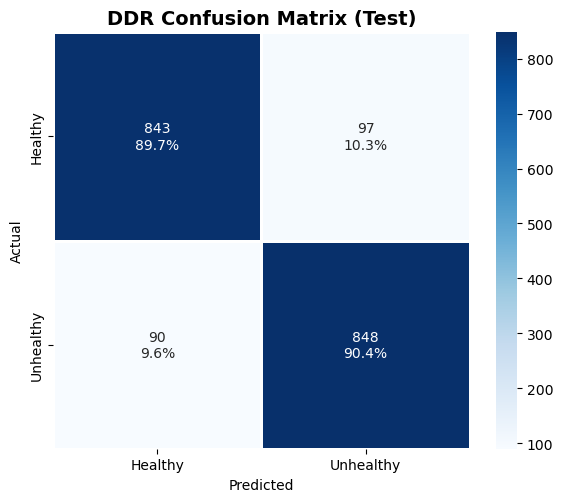

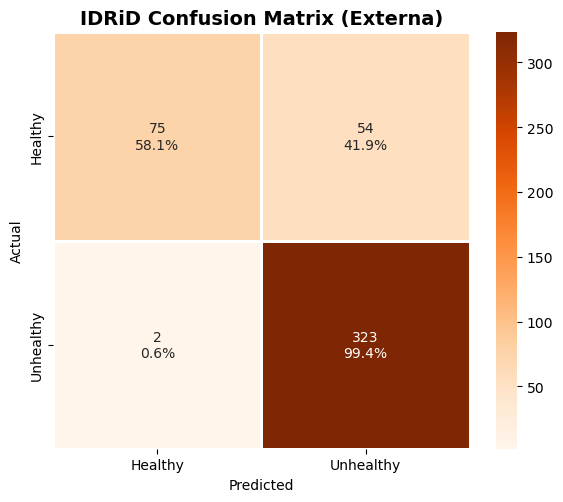

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# --------------------------------------------------
# Save these right after each evaluation if needed:
# aptos_results_df = results_df.copy()
# idrid_results_df = results_df.copy()
# --------------------------------------------------

def plot_conf_matrix(y_true, y_pred, title, labels=("Healthy", "Unhealthy"), cmap="Blues"):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    annot = np.array([
        [f"{cm[i, j]}\n{cm_pct[i, j]*100:.1f}%" for j in range(cm.shape[1])]
        for i in range(cm.shape[0])
    ])

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap=cmap,
        cbar=True,
        xticklabels=labels,
        yticklabels=labels,
        linewidths=1,
        linecolor="white",
        square=True,
    )
    plt.title(title, fontsize=14, weight="bold")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# =========================
# DDR
# =========================
# Assumes these already exist from your DDR evaluation:
# test_labels, test_preds
plot_conf_matrix(
    test_labels,
    test_preds,
    title="DDR Confusion Matrix (Test)",
    cmap="Blues"
)

# =========================
# APTOS
# =========================
# Assumes you saved:
# aptos_results_df = results_df.copy()
"""plot_conf_matrix(
    aptos_results_df["true_label"].astype(int),
    aptos_results_df["pred_label"].astype(int),
    title="APTOS Confusion Matrix",
    cmap="Greens"
)"""

# =========================
# IDRiD
# =========================
# Assumes you saved:
# idrid_results_df = results_df.copy()
plot_conf_matrix(
    idrid_results_df["true_label"].astype(int),
    idrid_results_df["pred_label"].astype(int),
    title="IDRiD Confusion Matrix (Externa)",
    cmap="Oranges"
)


In [23]:
# ===== IDRID + EXACT NOTEBOOK PREPROCESSING + TEST ON MODEL =====
import os
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torchvision import models, transforms
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

# -------------------------------------------------------
# 1. Resolve base path
# -------------------------------------------------------
BASE_CANDIDATES = [
    Path.cwd(),
    Path.home() / "SageMaker" / "IDRiD",
]

BASE = next((p for p in BASE_CANDIDATES if (p / "idrid_labels.csv").exists()), None)
if BASE is None:
    raise FileNotFoundError("Could not find IDRiD folder with idrid_labels.csv")

print("Using BASE:", BASE)

CSV_PATH = BASE / "idrid_labels.csv"
IMG_DIR = BASE / "Imagenes"

if not CSV_PATH.exists():
    raise FileNotFoundError(f"Missing CSV: {CSV_PATH}")
if not IMG_DIR.exists():
    raise FileNotFoundError(f"Missing image folder: {IMG_DIR}")

CKPT_CANDIDATES = [
    BASE / "best_binary_swin_t_fixed.pth",
    Path.home() / "SageMaker" / "binary_processed_output" / "best_binary_swin_t_fixed.pth",
    Path.home() / "SageMaker" / "binary_processed_output" / "best_binary_swin_t.pth",
    Path.home() / "SageMaker" / "binary_processed_output" / "best_dr_model.pth",
]
CHECKPOINT_PATH = next((p for p in CKPT_CANDIDATES if p.exists()), None)
if CHECKPOINT_PATH is None:
    raise FileNotFoundError(
        "No checkpoint found. Checked:\n" + "\n".join(str(p) for p in CKPT_CANDIDATES)
    )

print("Using checkpoint:", CHECKPOINT_PATH)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# -------------------------------------------------------
# 2. Build clean IDRiD dataframe with correct paths
# -------------------------------------------------------
df = pd.read_csv(CSV_PATH)
df.columns = [c.strip().lower() for c in df.columns]

# Drop junk unnamed columns
df = df.loc[:, ~df.columns.str.contains(r"^unnamed")].copy()

print("Columns found:", df.columns.tolist())

id_col = None
for c in ["id_code", "image_id", "image", "img", "filename", "file", "name"]:
    if c in df.columns:
        id_col = c
        break

label_col = None
for c in ["diagnosis", "label", "grade", "dr_grade", "class"]:
    if c in df.columns:
        label_col = c
        break

if id_col is None:
    raise ValueError(f"Could not find image column. Columns: {df.columns.tolist()}")

if label_col is None:
    raise ValueError(f"Could not find label column. Columns: {df.columns.tolist()}")

print("Using image column:", id_col)
print("Using label column:", label_col)

def build_image_map(folder: Path):
    image_map = {}
    for p in folder.rglob("*"):
        if p.is_file() and p.suffix.lower() in {".png", ".jpg", ".jpeg", ".tif", ".tiff"}:
            image_map[p.name] = str(p)
            image_map[p.stem] = str(p)
    return image_map

image_map = build_image_map(IMG_DIR)

def resolve_img(x):
    x = str(x).strip()
    return (
        image_map.get(x)
        or image_map.get(Path(x).name)
        or image_map.get(Path(x).stem)
        or image_map.get(f"{x}.png")
        or image_map.get(f"{x}.jpg")
        or image_map.get(f"{x}.jpeg")
        or image_map.get(f"{x}.tif")
        or image_map.get(f"{x}.tiff")
    )

df["full_path"] = df[id_col].apply(resolve_img)
df["binary_label"] = df[label_col].astype(int).apply(lambda x: 0 if x == 0 else 1)

before = len(df)
df = df[df["full_path"].notna()].reset_index(drop=True)
after = len(df)

print(f"Resolved images: {after}/{before}")

# Keep only useful columns
df = df[[id_col, label_col, "full_path", "binary_label"]].copy()
df.to_csv(BASE / "idrid_cross_val_ready.csv", index=False)

print("\nBinary label distribution:")
print(df["binary_label"].value_counts().sort_index())
display(df.head())

# -------------------------------------------------------
# 3. EXACT PREPROCESSING FROM YOUR NOTEBOOK
# -------------------------------------------------------
class GreenCLAHE(object):
    def __call__(self, img):
        rgb = np.array(img.convert("RGB"))
        green = rgb[:, :, 1]
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        green_clahe = clahe.apply(green)
        merged = cv2.merge([green_clahe, green_clahe, green_clahe])
        return Image.fromarray(merged)

class BenGrahamCircleCrop(object):
    def __init__(self, threshold=20, margin=0.02, fill_outside_mode="mean", min_radius_ratio=0.15):
        self.threshold = threshold
        self.margin = margin
        self.fill_outside_mode = fill_outside_mode
        self.min_radius_ratio = min_radius_ratio

    def __call__(self, img):
        rgb = np.array(img.convert("RGB"))
        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
        mask = (gray > self.threshold).astype(np.uint8) * 255
        if mask.max() == 0:
            return img

        kernel = np.ones((9, 9), dtype=np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return img

        contour = max(contours, key=cv2.contourArea)
        (cx, cy), radius = cv2.minEnclosingCircle(contour)
        h, w = gray.shape
        if radius < min(h, w) * self.min_radius_ratio:
            return img

        radius = int(np.ceil(radius * (1.0 + self.margin)))
        center = (int(round(cx)), int(round(cy)))
        circle_mask = np.zeros((h, w), dtype=np.uint8)
        cv2.circle(circle_mask, center, radius, 255, thickness=-1)
        inside = circle_mask > 0

        if self.fill_outside_mode == "mean" and inside.any():
            fill_color = rgb[inside].mean(axis=0).astype(np.uint8)
            filled = np.broadcast_to(fill_color.reshape(1, 1, 3), rgb.shape).copy()
            filled[inside] = rgb[inside]
        else:
            filled = cv2.bitwise_and(rgb, rgb, mask=circle_mask)

        x0 = max(center[0] - radius, 0)
        y0 = max(center[1] - radius, 0)
        x1 = min(center[0] + radius, w)
        y1 = min(center[1] + radius, h)
        cropped = filled[y0:y1, x0:x1]
        if cropped.size == 0:
            return img
        return Image.fromarray(cropped)

class LocalAverageColorSubtract(object):
    def __init__(self, sigma_ratio=1.0 / 30.0):
        self.sigma_ratio = sigma_ratio

    def __call__(self, img):
        rgb = np.array(img.convert("RGB"))
        sigma = max(max(rgb.shape[:2]) * self.sigma_ratio, 1.0)
        normalized = cv2.addWeighted(
            rgb,
            4.0,
            cv2.GaussianBlur(rgb, (0, 0), sigma),
            -4.0,
            128,
        )
        return Image.fromarray(normalized)

IMAGE_SIZE = 224

PREPROCESS_PIL = transforms.Compose([
    BenGrahamCircleCrop(threshold=20, margin=0.02, fill_outside_mode="mean"),
    LocalAverageColorSubtract(sigma_ratio=1.0 / 30.0),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    GreenCLAHE(),
])

normalize_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

def preprocess_for_inference(img_path):
    img = Image.open(img_path).convert("RGB")
    return PREPROCESS_PIL(img)

# -------------------------------------------------------
# 4. Load model + threshold
# -------------------------------------------------------
ck = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)

best_threshold = ck.get("best_threshold", 0.5) if isinstance(ck, dict) else 0.5
best_params = ck.get("best_params", {}) if isinstance(ck, dict) else {}
dropout = best_params.get("dropout", 0.2)

model = models.swin_t(weights=None)
in_features = model.head.in_features
model.head = nn.Sequential(
    nn.Dropout(p=dropout),
    nn.Linear(in_features, 1)
)

state = ck["model_state_dict"] if isinstance(ck, dict) and "model_state_dict" in ck else ck
state = {k.replace("module.", ""): v for k, v in state.items()}
model.load_state_dict(state, strict=False)
model.to(DEVICE)
model.eval()

print("Loaded threshold:", best_threshold)
print("Loaded dropout:", dropout)

# -------------------------------------------------------
# 5. Run inference on IDRiD
# -------------------------------------------------------
all_probs = []
all_preds = []
all_labels = []
kept_rows = []
missing_files = 0
bad_images = 0

print(f"\nRunning inference on {len(df)} IDRiD images...")

with torch.no_grad():
    for row in df.itertuples(index=False):
        p = row.full_path

        if not os.path.exists(p):
            missing_files += 1
            continue

        try:
            processed_img = preprocess_for_inference(p)
            inp = normalize_transform(processed_img).unsqueeze(0).to(DEVICE)

            out = model(inp)
            if out.ndim == 2 and out.size(1) == 1:
                out = out[:, 0]

            prob = torch.sigmoid(out).item()
            pred = 1 if prob >= best_threshold else 0

            all_probs.append(prob)
            all_preds.append(pred)
            all_labels.append(int(row.binary_label))

            kept_rows.append({
                "id_code": getattr(row, id_col),
                "true_label": int(row.binary_label),
                "pred_label": pred,
                "prob": prob,
                "full_path": row.full_path,
            })

        except Exception as e:
            bad_images += 1
            print("Skipped:", p, "|", e)

results_df = pd.DataFrame(kept_rows)
results_df.to_csv(BASE / "idrid_predictions.csv", index=False)

print("\nProcessed:", len(all_preds))
print("Missing files:", missing_files)
print("Bad images:", bad_images)

if len(all_preds) == 0:
    raise ValueError("No IDRiD images were processed. Check paths or preprocessing.")

# -------------------------------------------------------
# 6. Metrics
# -------------------------------------------------------
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, zero_division=0)
recall = recall_score(all_labels, all_preds, zero_division=0)
f1 = f1_score(all_labels, all_preds, zero_division=0)
auc_roc = roc_auc_score(all_labels, all_probs)

print("\n" + "=" * 45)
print("IDRID EXTERNAL RESULTS")
print("=" * 45)
print(f"Samples used:      {len(all_labels)}")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"Recall (Sens.):    {recall:.4f}")
print(f"F1-Score:          {f1:.4f}")
print(f"AUC-ROC:           {auc_roc:.4f}")
print(f"Applied Threshold: {best_threshold:.4f}")
print("=" * 45)

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Healthy", "Unhealthy"], zero_division=0))

print("\nSaved:")
print(BASE / "idrid_cross_val_ready.csv")
print(BASE / "idrid_predictions.csv")


Using BASE: /home/ec2-user/SageMaker/IDRiD
Using checkpoint: /home/ec2-user/SageMaker/binary_processed_output/best_binary_swin_t_fixed.pth
Using device: cuda
Columns found: ['id_code', 'diagnosis', 'risk of macular edema']
Using image column: id_code
Using label column: diagnosis
Resolved images: 454/455

Binary label distribution:
binary_label
0    129
1    325
Name: count, dtype: int64


,id_code,diagnosis,full_path,binary_label
0,IDRiD_002,3,/home/ec2-user/SageMaker/IDRiD/Imagenes/Imagen...,1
1,IDRiD_003,2,/home/ec2-user/SageMaker/IDRiD/Imagenes/Imagen...,1
2,IDRiD_004,3,/home/ec2-user/SageMaker/IDRiD/Imagenes/Imagen...,1
3,IDRiD_005,4,/home/ec2-user/SageMaker/IDRiD/Imagenes/Imagen...,1
4,IDRiD_006,4,/home/ec2-user/SageMaker/IDRiD/Imagenes/Imagen...,1


Loaded threshold: 0.5005577206611633
Loaded dropout: 0.10531542163373908

Running inference on 454 IDRiD images...

Processed: 454
Missing files: 0
Bad images: 0

IDRID EXTERNAL RESULTS
Samples used:      454
Accuracy:          0.8767
Precision:         0.8568
Recall (Sens.):    0.9938
F1-Score:          0.9202
AUC-ROC:           0.9678
Applied Threshold: 0.5006

Confusion Matrix:
[[ 75  54]
 [  2 323]]

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.97      0.58      0.73       129
   Unhealthy       0.86      0.99      0.92       325

    accuracy                           0.88       454
   macro avg       0.92      0.79      0.82       454
weighted avg       0.89      0.88      0.87       454


Saved:
/home/ec2-user/SageMaker/IDRiD/idrid_cross_val_ready.csv
/home/ec2-user/SageMaker/IDRiD/idrid_predictions.csv


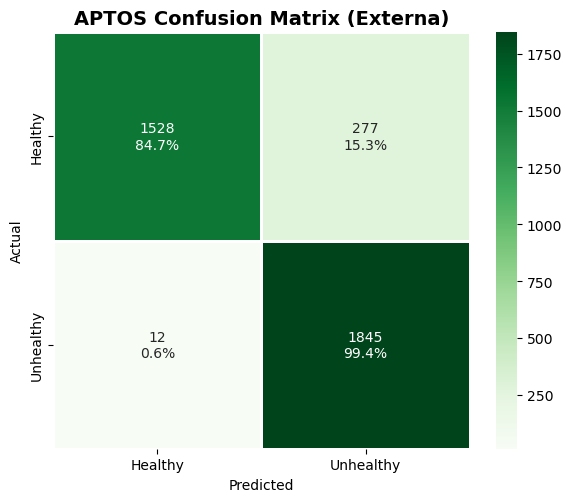

In [26]:
# =========================
# APTOS
# =========================
aptos_cm = np.array([
    [1528, 277],
    [12, 1845]
])

def plot_conf_matrix_from_values(cm, title, labels=("Healthy", "Unhealthy"), cmap="Greens"):
    cm_pct = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    annot = np.array([
        [f"{cm[i, j]}\n{cm_pct[i, j]*100:.1f}%" for j in range(cm.shape[1])]
        for i in range(cm.shape[0])
    ])

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap=cmap,
        cbar=True,
        xticklabels=labels,
        yticklabels=labels,
        linewidths=1,
        linecolor="white",
        square=True,
    )
    plt.title(title, fontsize=14, weight="bold")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

plot_conf_matrix_from_values(
    aptos_cm,
    title="APTOS Confusion Matrix (Externa)",
    cmap="Greens"
)


In [33]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def tune_binary_threshold(df, prob_col="prob", label_col="true_label", metric="f1"):
    y_true = df[label_col].astype(int).to_numpy()
    y_prob = df[prob_col].astype(float).to_numpy()

    thresholds = np.linspace(0.0, 1.0, 1001)
    rows = []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        rows.append({
            "threshold": t,
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
        })

    thresh_df = pd.DataFrame(rows)
    best_row = thresh_df.sort_values(metric, ascending=False).iloc[0]
    return thresh_df, best_row

idrid_thresh_df, best_idrid = tune_binary_threshold(
    idrid_results_df,
    prob_col="prob",
    label_col="true_label",
    metric="f1"   # change to "recall", "precision", or "accuracy" if you want
)

print(best_idrid)
best_threshold = float(best_idrid["threshold"])

idrid_results_df["pred_label_tuned"] = (
    idrid_results_df["prob"].astype(float) >= best_threshold
).astype(int)

print("Best threshold:", best_threshold)
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(
    idrid_results_df["true_label"].astype(int),
    idrid_results_df["pred_label_tuned"].astype(int)
)
print(cm)

print(classification_report(
    idrid_results_df["true_label"].astype(int),
    idrid_results_df["pred_label_tuned"].astype(int),
    target_names=["Healthy", "Unhealthy"]
))


threshold    0.998000
accuracy     0.914097
precision    0.918129
recall       0.966154
f1           0.941529
Name: 998, dtype: float64
Best threshold: 0.998
[[101  28]
 [ 11 314]]
              precision    recall  f1-score   support

     Healthy       0.90      0.78      0.84       129
   Unhealthy       0.92      0.97      0.94       325

    accuracy                           0.91       454
   macro avg       0.91      0.87      0.89       454
weighted avg       0.91      0.91      0.91       454



In [28]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_auc_curve(y_true, y_score, title="ROC Curve"):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", linewidth=2)
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title, fontsize=14, weight="bold")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


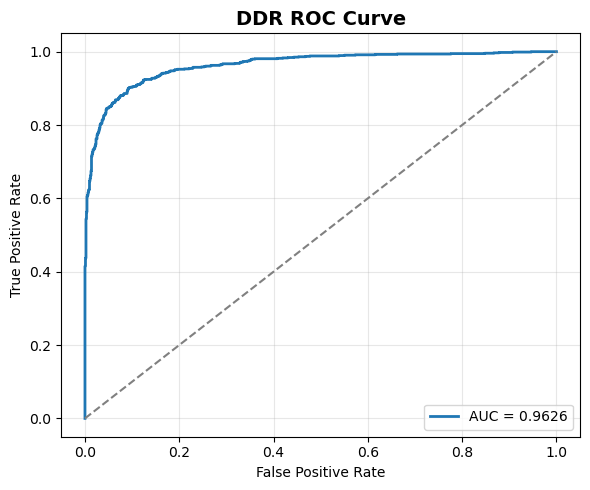

In [32]:
plot_auc_curve(
    test_labels,
    test_probs,
    title="DDR ROC Curve"
)


In [ ]:
from pathlib import Path
import copy
import torch

save_path = Path.cwd() / "final sdp2 binary model.pth"

if "best_state" in globals() and best_state is not None:
    state_dict = copy.deepcopy(best_state)
elif "best_model_state" in globals() and best_model_state is not None:
    state_dict = copy.deepcopy(best_model_state)
elif "model" in globals():
    state_dict = copy.deepcopy(model.state_dict())
else:
    raise NameError("Couldn't find `best_state`, `best_model_state`, or `model` in memory.")

checkpoint = {
    "model_state_dict": state_dict,
    "best_threshold": 0.5005577206611633,  
}

for var_name in ["best_params", "history", "model_name", "IMAGE_SIZE", "SEED", "NUM_CLASSES"]:
    if var_name in globals():
        value = globals()[var_name]
        key = var_name.lower() if var_name.isupper() else var_name
        checkpoint[key] = value

torch.save(checkpoint, save_path)
print(f"Saved untuned binary model to: {save_path}")
